# 03-06-2025

In [1]:
import pandas as pd                          #data frame
import numpy as np                                #maths
import matplotlib.pyplot as plt          #plotting graph
import seaborn as sns     #data visualization and graphs

In [2]:
df = pd.read_excel("Telco_customer_churn.xlsx")

In [3]:
df.shape

(7043, 33)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [5]:
df['Churn Label'].value_counts()

,count
Churn Label,
No,5174
Yes,1869


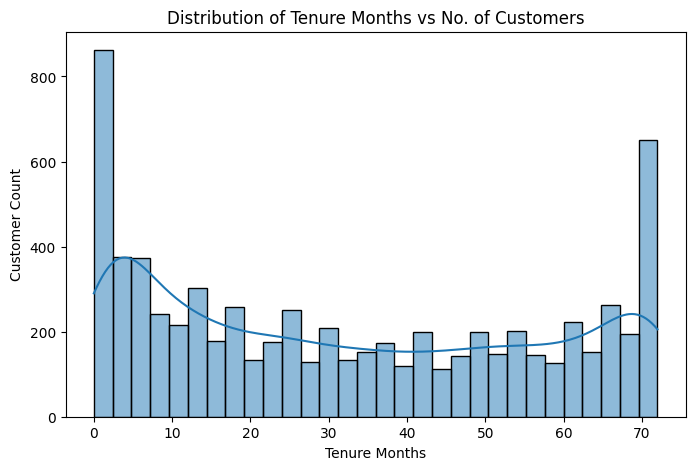

In [6]:
plt.figure(figsize=(8,5))
sns.histplot(df['Tenure Months'], bins = 30, kde = True)
plt.xlabel('Tenure Months')
plt.ylabel('Customer Count')
plt.title('Distribution of Tenure Months vs No. of Customers')
plt.show()

In [7]:
df["Tenure Months"].max()
df["Tenure Months"].min()

0

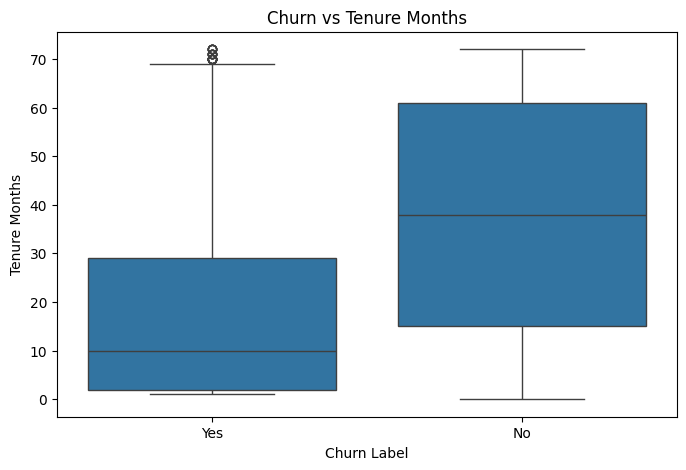

In [8]:
plt.figure(figsize=(8,5))
sns.boxplot(x = 'Churn Label', y = 'Tenure Months', data = df)
plt.xlabel('Churn Label')
plt.ylabel('Tenure Months')
plt.title('Churn vs Tenure Months')
plt.show()

### **Analysis of this Graph**
For yes,
Median is 10. 50% people leaving company leaves in first 10 months.

For no,
If a person stayed for 37-38 months, he will stay.

In [9]:
df['Churn Label'] == 'Yes'

,Churn Label
0,True
1,True
2,True
3,True
4,True
...,...
7038,False
7039,False
7040,False
7041,False


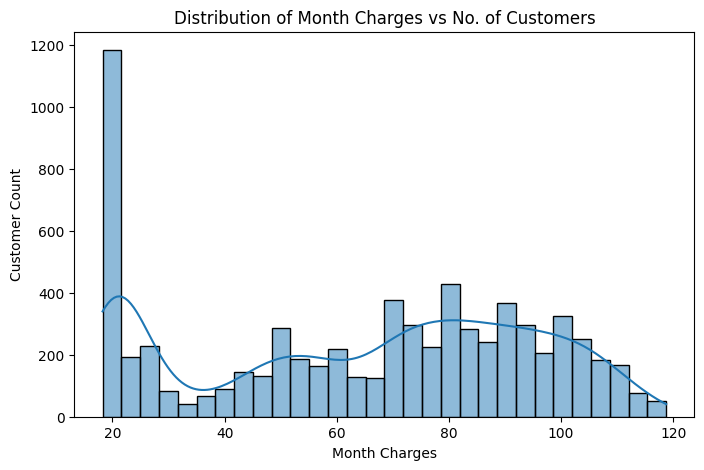

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(df['Monthly Charges'], bins = 30, kde = True)
plt.xlabel('Month Charges')
plt.ylabel('Customer Count')
plt.title('Distribution of Month Charges vs No. of Customers')
plt.show()

### **ANALYSIS OF GRAPH**
Minimum monthly charge is 18. Maximum customers prefer low charges. Maximum is 118. Very few people who choose to pay that rate.

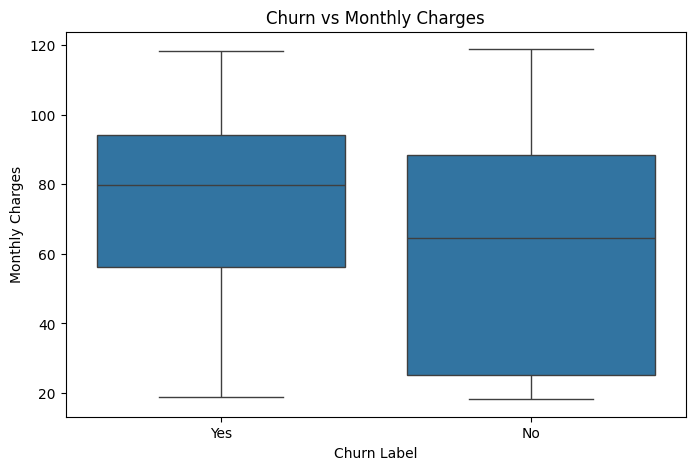

In [11]:
plt.figure(figsize=(8,5))
sns.boxplot(x = 'Churn Label', y = 'Monthly Charges', data = df)
plt.xlabel('Churn Label')
plt.ylabel('Monthly Charges')
plt.title('Churn vs Monthly Charges')
plt.show()

### **Analysis of Graph**

50% people leaving leave when charges reach 80.

50% of people not leaving company are fine till charges are 63.

In [12]:
df[df['Churn Label'] == 'Yes']['Monthly Charges'].quantile([0.25, 0.5, 0.75])

,Monthly Charges
0.25,56.15
0.50,79.65
0.75,94.20


In [13]:
#Percentile values nikalna for 'Yes'

In [14]:
df['Monthly Charges'].describe()  # check ki kya hua isse

,Monthly Charges
count,7043.000000
mean,64.761692
std,30.090047
min,18.250000
25%,35.500000
50%,70.350000
75%,89.850000
max,118.750000


In [15]:
df['Contract'].unique()

array(['Month-to-month', 'Two year', 'One year'], dtype=object)

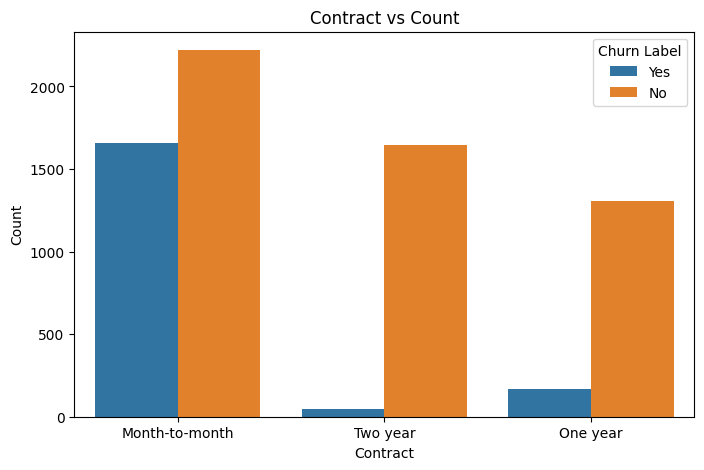

In [16]:
plt.figure(figsize=(8,5))
sns.countplot(x = 'Contract', hue = 'Churn Label', data = df) #hue se categories aa jaati h(Yes / No)
plt.xlabel('Contract')
plt.ylabel('Count')
plt.title('Contract vs Count')
plt.show()

## **SUMMARY SO FAR**
1. **Tenure:** Newer customers (low tenure) are highly prone to churning.

2. **Monthly Charges:** Customers with higher monthly bills are more likely to churn.

3. **Contract Type**: Month-to-month contracts are strongly associated with a higher churn rate, while longer-term contracts indicate customer loyalty.

# 05-06-2025

In [17]:
df['Internet Service'].unique()

array(['DSL', 'Fiber optic', 'No'], dtype=object)

In [18]:
# DSL is digital subscriber line.

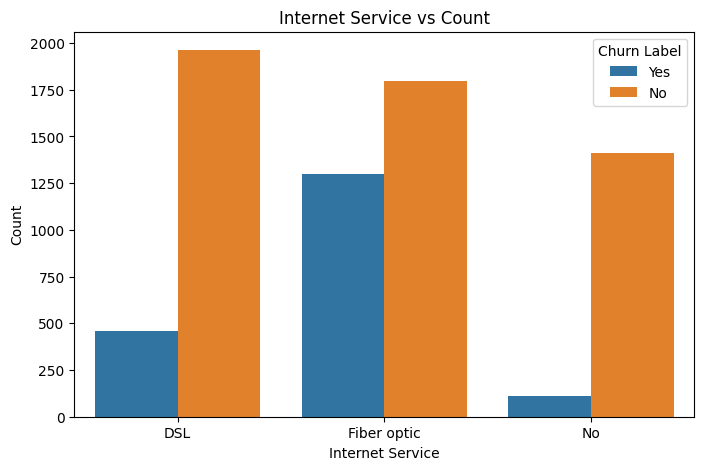

In [19]:
plt.figure(figsize=(8,5))
sns.countplot(x = 'Internet Service', hue = 'Churn Label', data = df) #hue se categories aa jaati h(Yes / No)
plt.xlabel('Internet Service')
plt.ylabel('Count')
plt.title('Internet Service vs Count')
plt.show()

1. No is more as premium plan krne mein koi dikkat aa jaaye, toh kya faayda. Therefore No wale mein good retention rate.
2. DSL is not so mehengi. So poeple who cannot afford will stay as it is lowest option.
3. Fibre cable is mehengi, so leaving is high.


In [20]:
df['Payment Method'].unique()

array(['Mailed check', 'Electronic check', 'Bank transfer (automatic)',
       'Credit card (automatic)'], dtype=object)

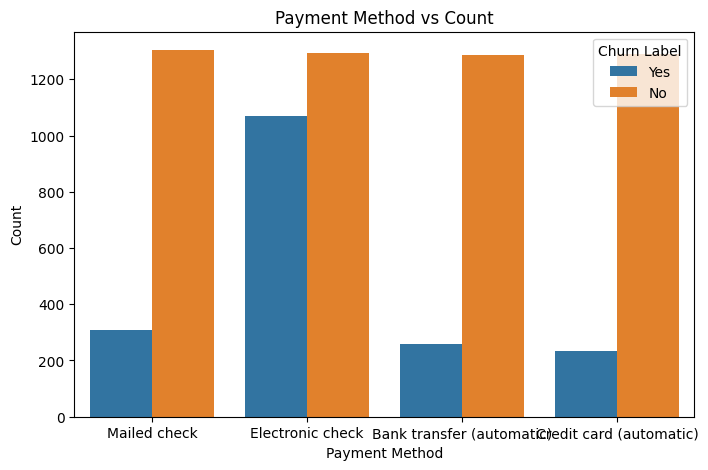

In [21]:
plt.figure(figsize=(8,5))
sns.countplot(x = 'Payment Method', hue = 'Churn Label', data = df) #hue se categories aa jaati h(Yes / No)
plt.xlabel('Payment Method')
plt.ylabel('Count')
plt.title('Payment Method vs Count')
plt.show()

1. automatic h toh bina puche payment ho jaayegi, itna dhyaan nhi. manual hogi toh har baar payment krte hue sochoge ki itne paise iss cheez mein lag rhe h, wagarah wagarah.

2. Find the difference between mailed check and electronic check (homework).

In [22]:
df['Tech Support'].unique()

array(['No', 'Yes', 'No internet service'], dtype=object)

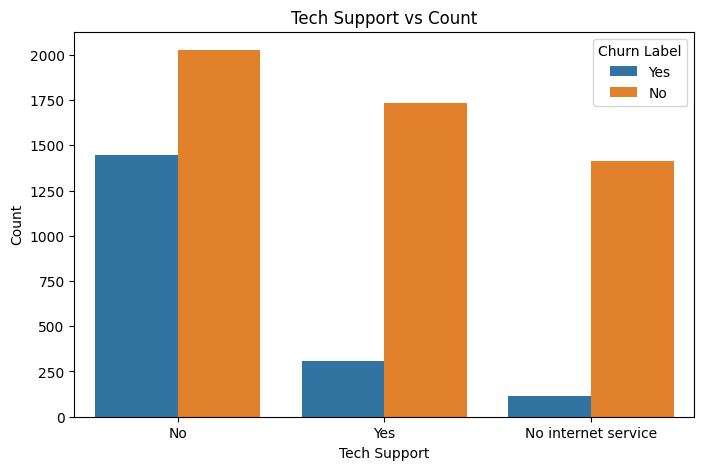

In [23]:
plt.figure(figsize=(8,5))
sns.countplot(x = 'Tech Support', hue = 'Churn Label', data = df) #hue se categories aa jaati h(Yes / No)
plt.xlabel('Tech Support')
plt.ylabel('Count')
plt.title('Tech Support vs Count')
plt.show()

In [24]:
avg_tenure = df.groupby('Churn Label')['Tenure Months'].mean()
print(avg_tenure)

Churn Label
No     37.569965
Yes    17.979133
Name: Tenure Months, dtype: float64


Find the avg. number of months of churn and retention

1. Group all customers by churn label
2. Use aggregrate function avg() on tenure months - mean()

## **What is Correlation??**

Tell the relation bwtween related data (age, time).

If x increases, will y inc/dec/stay same?

correlation = [-1, 1]

Build a correlation matrix and print it.
Check: pandas.DataFrame.corr on google.

In [25]:
numerical_cols = ['Tenure Months', 'Monthly Charges', 'Churn Value', 'Churn Score', 'CLTV']
correlation_matrix = df[numerical_cols].corr()

print(correlation_matrix)

                 Tenure Months  Monthly Charges  Churn Value  Churn Score  \
Tenure Months         1.000000         0.247900    -0.352229    -0.224987   
Monthly Charges       0.247900         1.000000     0.193356     0.133754   
Churn Value          -0.352229         0.193356     1.000000     0.664897   
Churn Score          -0.224987         0.133754     0.664897     1.000000   
CLTV                  0.396406         0.098693    -0.127463    -0.079782   

                     CLTV  
Tenure Months    0.396406  
Monthly Charges  0.098693  
Churn Value     -0.127463  
Churn Score     -0.079782  
CLTV             1.000000  


In [26]:
correlation_matrix

,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
Tenure Months,1.000000,0.247900,-0.352229,-0.224987,0.396406
Monthly Charges,0.247900,1.000000,0.193356,0.133754,0.098693
Churn Value,-0.352229,0.193356,1.000000,0.664897,-0.127463
Churn Score,-0.224987,0.133754,0.664897,1.000000,-0.079782
CLTV,0.396406,0.098693,-0.127463,-0.079782,1.000000


This was univariate analysis. Let's do bivariate analysis. [Yes / No]

Therefore, we use crosstab for categorical correlation.

In [27]:
contract_churn = pd.crosstab(df['Contract'], df['Churn Label'], normalize = 'index')
contract_churn

Churn Label,No,Yes
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319


Upar jo graph bnaya tha of contract vs churn, ussi ki tabular representation.

Third parameter passed is to normalize, i.e.value ko percentage mein convert krna, based on row or column.

Check docs: crosstab

# **Data Cleaning**
missing / duplicate / encoding

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [29]:
df['Total Charges']

,Total Charges
0,108.15
1,151.65
2,820.5
3,3046.05
4,5036.3
...,...
7038,1419.4
7039,1990.5
7040,7362.9
7041,346.45


In [30]:
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors = 'coerce')
df['Total Charges']

#coerce empty string ko 0 bna deta h

,Total Charges
0,108.15
1,151.65
2,820.50
3,3046.05
4,5036.30
...,...
7038,1419.40
7039,1990.50
7040,7362.90
7041,346.45


#09-06-2026

In [31]:
df['Total Charges'].isnull().sum()

np.int64(11)

11 missing values mean I need to fill it / drop it.

Let every company generate monthly charge at 9th of each month. A person opt plan at 1 of month. So at 9th of that month, total charge will be 0 (i.e. he/she is fresher).

Therefore, these are not missing values, these are logically correct.

In [32]:
df[df['Total Charges'].isnull()]['Tenure Months']

,Tenure Months
2234,0
2438,0
2568,0
2667,0
2856,0
4331,0
4687,0
5104,0
5719,0
6772,0


### Class cancelled due to technical issues 😢😢

# 10-06-2026

In [33]:
df[df['Total Charges'].isnull()]['Tenure Months'].shape

# why not (11, 1)?

(11,)

When you select a single column from a DataFrame, like df['Tenure Months'], the result is a pandas Series, not a DataFrame. A pandas Series is a 1-dimensional data structure, so its .shape attribute returns a tuple with a single element representing the number of rows. If you wanted a 2-dimensional result (a DataFrame with one column), you would need to select the column using double brackets, like df[['Tenure Months']].

In [34]:
df['Total Charges'] = df['Total Charges'].fillna(0)
df['Total Charges'].isnull().sum()

# fillna(n) fills all NULL values of a column by 'n'

np.int64(0)

7 columns can be dropped as they do not affect churn factor.

But, we need to drop churn label, churn score, CLTV, churn reason. Why?

Ex: Let a model predicts if a student passed/failed, on a dataset. Let columns be attendance, IQ, achievments, pass/fail certificate.

**Data Leakage** - Output is already given as input.

Here, model ne kaam kiya hi nhi.

Similarly, the above 4 columns are already containing answers to whether customer will leave or stay, causing data leakage. Hence, model will accidentally get information about the answer.

**Ques. **Don't we require these 4 models for training the model?
**Ans.** We have churn value, which is enough. Don't need other columns. If we drop churn value, we need to keep churn label. But churn value is preferred as numeric.

In [35]:
drop_cols = [
    'CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code', 'Lat Long', 'Longitude', 'Latitude', 'Churn Label', 'Churn Score', 'CLTV', 'Churn Reason'
]

In [36]:
df = df.drop(columns = drop_cols)

In [37]:
df.shape

(7043, 20)

### Encoding

Now we'll start encoding.
We'll do on cities, and drop one column in the end.

We use **pd.get_dummies** for encoding. Check docs.

In [38]:
df_encoded = pd.get_dummies(df, drop_first = True)
df_encoded.head()

# What does .head() do?


,Tenure Months,Monthly Charges,Total Charges,Churn Value,Gender_Male,Senior Citizen_Yes,Partner_Yes,Dependents_Yes,Phone Service_Yes,Multiple Lines_No phone service,...,Streaming TV_No internet service,Streaming TV_Yes,Streaming Movies_No internet service,Streaming Movies_Yes,Contract_One year,Contract_Two year,Paperless Billing_Yes,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check
0,2,53.85,108.15,1,True,False,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
1,2,70.70,151.65,1,False,False,False,True,True,False,...,False,False,False,False,False,False,True,False,True,False
2,8,99.65,820.50,1,False,False,False,True,True,False,...,False,True,False,True,False,False,True,False,True,False
3,28,104.80,3046.05,1,False,False,True,True,True,False,...,False,True,False,True,False,False,True,False,True,False
4,49,103.70,5036.30,1,True,False,False,True,True,False,...,False,True,False,True,False,False,True,False,False,False


In [39]:
df_encoded.shape

# itne saare columns, therefore we need to drop more. Therefore dropping 'city' column.

(7043, 31)

Now, from df_encoded, all columns are input columns except churn value. and churn value is the only output columns.

In [40]:
x = df_encoded.drop(columns = ['Churn Value'])
y = df_encoded['Churn Value']

# or
# x = df_encoded.drop('Churn Value', axis = 1)
# y = df_encoded['Churn Value']

# axis specifies coln ya row, kya remove krni h

# Machine Learning Implementation

Check **train_test_split** on scikit-learn.org. Check docs.

In [41]:
from sklearn.model_selection import train_test_split

In [42]:
X_train, X_test, Y_train, Y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

# pehle dono X wale variables, phir Y wale

# test size = 0.2 [20% data testing, 80% data training]
# random test = 42[splitting is random. 42 means same rows upar neeche jaayengi, chahe kitni baar code chala lo. If no 42, then some row may goto train on 1 run, on test to another]

HW: Same model and different model se accuracy improve krni h.

Model used by sir - **Random Forest Classifier**.

**How decision tree works?**
1. Take the data set.
2. Take best features to split the data.
3. Split your data.
4. Repeat.
5. Stop when either
  5.1. no feature left or
  5.2. data is pure

  Search **KNN** and **KMEAN** and **SCALING**. They depend on their neighbours [Sanagti ka asar].

  Let one black dot surrounded by red and green dots. If K = 5, jo 5 nearest honge, unmein se majority mein jo hoga, uska behaviour vo ho jaayega.

**Advantages of Decision Tree**
1. No scaling in decision tree.
2. ML model learn all rules and logics efficiently via splitting.

**Which feature we need to split?**
Datasets can be pure and impure. You need to split in such a way that leaf node is always pure.
**Entropy** measures impurity. [Check docs of decision tree and random forest].
```
Entropy = 0
for(int i = 1; i <= n; i ++) {

  Entropy += Pi * log Pi
}
Entropy *= -1
# Pi is probability of ith value of category.
```
**Information Gain** = Entropy(Parent) - Weighted Entropy(Child)

[
1. Parent will always be o/p column.
2. weighted = Sum of (Pi * Entropy(category))
]

Information Gain must be found out for each feature. [Check personal recording for how to calculate.]

## Random Forest
Random Forest = Group of decision trees

Entire data is divided into multiple decision trees [Ensemble].  Sab kuch naa kuch output denge. Jo majority output hoga, usse answer maan lenge.

Here, our random forest will do churn prediction.

*In ML, accuracy is not always the factor in industries. Sometimes we use **confusion matrix**.*

In [43]:
from sklearn.ensemble import RandomForestClassifier

In [44]:
rf_model = RandomForestClassifier(n_estimators = 100, random_state = 42)
rf_model.fit(X_train, Y_train)

# fit is used to develop the logic after data observation

RandomForestClassifier(random_state=42)

In [45]:
y_pred = rf_model.predict(X_test)
y_pred

array([0, 0, 0, ..., 1, 0, 1])

Now we will check accuracy. Till now, model created, made logic on trains, tested on X_test to output y_pred which will be checked again Y_test.

In [46]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(Y_test, y_pred)
accuracy

0.7856635911994322

**Does accuracy matter to me for this problem statement?**

Accuracy never tells me about type 1 error and type 2 error.

**Confusion Matrix:**

Placed - 1, Unplaced - 0

Predicted values as columns, actual values as rows.

**Precision** = TP / (TP + FP)

Actually placed out of total shown placed.

**Recall** = TP / (TP + FN)

Actually placed out of how many my model has correctly predicted

In [47]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(Y_test, y_pred)
print(cm)

# print gives matrix, normal gives array

[[902 107]
 [195 205]]


In [48]:
from sklearn.metrics import classification_report

cr = classification_report(Y_test, y_pred)
print(cr)

              precision    recall  f1-score   support

           0       0.82      0.89      0.86      1009
           1       0.66      0.51      0.58       400

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.72      1409
weighted avg       0.78      0.79      0.78      1409



Therefore, maximize recall and keep accuracy optimum.

Maine bola tha jitne churn krenge, unmein se 66% churned. Jo company chodd rhe h, model unhe predict kre (recall). Cuurently model jo nhi chod rhe, unhe sahi predict kr rha h. I want jo chodde, unhe sahi kre. 51% recall is very bad (we need atleast 70%).

Medical sector mein precision matters i.e. jo asli mein bimar h, bas unhe sahi predict kre. Agar koi bimaar nhi h, and model ne keh diya bimar h, toh dikkat ho jaayegi.

**How to increase recall?**

Approach 1:
Handle class imbalance **bold text**

Out of 7403, not leaving were 5k, leaving were 2k. Toh model ko aisa hi lgega ki naa chodne wala zyada h. Therefore, 51% recall.

In [49]:
balanced_rf_model = RandomForestClassifier(n_estimators = 100, class_weight = 'balanced', random_state = 42)
balanced_rf_model.fit(X_train, Y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [50]:
balanced_y_pred = balanced_rf_model.predict(X_test)
balanced_y_pred

array([0, 0, 0, ..., 1, 0, 1])

In [51]:
balanced_accuracy = accuracy_score(Y_test, balanced_y_pred)
balanced_accuracy

0.7920511000709723

In [52]:
balanced_cm = confusion_matrix(Y_test, balanced_y_pred)
print(balanced_cm)

[[907 102]
 [191 209]]


In [53]:
balanced_cr = classification_report(Y_test, balanced_y_pred)
print(balanced_cr)

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1009
           1       0.67      0.52      0.59       400

    accuracy                           0.79      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.78      0.79      0.78      1409



**Approach 2: Hyper Parameter Tuning**

Changing (tuning) parameters - n_estimators [bettre learning], max_depth

In [54]:
tuned_rf_model = RandomForestClassifier(n_estimators = 300, max_depth = 10, random_state = 42, class_weight='balanced')
tuned_rf_model.fit(X_train, Y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=300,
                       random_state=42)

In [55]:
tuned_y_pred = tuned_rf_model.predict(X_test)
tuned_y_pred

array([1, 0, 0, ..., 1, 0, 1])

In [56]:
tuned_accuracy = accuracy_score(Y_test, tuned_y_pred)
tuned_accuracy

0.7828246983676366

In [57]:
tuned_cm = confusion_matrix(Y_test, tuned_y_pred)
print(tuned_cm)

[[804 205]
 [101 299]]


In [58]:
tuned_cr = classification_report(Y_test, tuned_y_pred)
print(tuned_cr)

              precision    recall  f1-score   support

           0       0.89      0.80      0.84      1009
           1       0.59      0.75      0.66       400

    accuracy                           0.78      1409
   macro avg       0.74      0.77      0.75      1409
weighted avg       0.80      0.78      0.79      1409



**HomeWork** : Change values of n_estimator / max_depth keeping other fixed to see which matters more.

KNN & RocCurve